# BDD100K Scene Classification — Combined Feature Extraction


## 1. Mount Drive and locate the shared project folder

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import glob
hits = glob.glob('/content/drive/MyDrive/DATASCI 281*/BDD100k DATA')
print(hits)
BASE = hits[0]
print("BASE =", BASE)

Mounted at /content/drive
['/content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA']
BASE = /content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA


## 2. Load the manifest and build the shared dev sample


In [2]:
import pandas as pd

df = pd.read_csv(f'{BASE}/scene_manifest.csv')
print(df['scene'].value_counts())

CAP = 1200
sample = (df.groupby('scene', group_keys=False)
            .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))
            .reset_index(drop=True))
print(sample['scene'].value_counts())
print(len(sample), "images in dev sample")

scene
city street     49693
highway         19913
residential      9358
parking lot       427
tunnel            156
gas stations       34
Name: count, dtype: int64
scene
city street     1200
highway         1200
residential     1200
parking lot      427
tunnel           156
gas stations      34
Name: count, dtype: int64
4217 images in dev sample


/tmp/ipykernel_1347/3554300430.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))


## 3. Verify images are reachable (unzip if this is a fresh session)
Run the check first. If it reports missing files, run the unzip + rename cells below, then re-check.

In [3]:
import os

missing = sum(not os.path.exists(p) for p in sample['img_path'].head(20))
print(f"{missing}/20 checked — should be 0")

20/20 checked — should be 0


### 3a. Only run this if step 3 showed missing images

In [4]:
!unzip -q "{BASE}/bdd100k_images_100k.zip" -d /content/data

In [5]:
import os
# Colab's extracted folder is sometimes named '100k' instead of '100k_images'
if os.path.exists('/content/data/100k') and not os.path.exists('/content/data/100k_images'):
    os.rename('/content/data/100k', '/content/data/100k_images')

missing = sum(not os.path.exists(p) for p in sample['img_path'].head(20))
print(f"{missing}/20 checked — should be 0")

0/20 checked — should be 0


## 4. Feature extraction functions
Combined from both notebooks. `feat_hsv_regions` (region-wise HSV, the team's primary color feature) is identical to what would otherwise be called `feat_region_hsv` in the ablation — kept under one name to avoid duplicate computation.

In [6]:
import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern

IMG_W, IMG_H = 256, 144   # keep 16:9, small enough to be fast

def load_img(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (IMG_W, IMG_H))

# --- Primary features

def feat_hsv_regions(img, bins=16):
    """Region-wise HSV histograms over top/middle/bottom bands. (= region_hsv in the ablation)"""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h = img.shape[0]
    bands = [hsv[:h//3], hsv[h//3:2*h//3], hsv[2*h//3:]]
    feats = []
    for band in bands:
        for ch in range(3):
            hist = cv2.calcHist([band], [ch], None, [bins], [0, 256]).flatten()
            feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 bands x 3 ch x 16 bins = 144 dims

def feat_hog(img):
    """HOG on grayscale — edge density/orientation."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=9, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), feature_vector=True)

def feat_lbp(img, P=8, R=1):
    """Uniform LBP histogram — micro-texture, cheap."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    hist, _ = np.histogram(lbp, bins=P+2, range=(0, P+2))
    return hist / (hist.sum() + 1e-8)

# --- Color histogram ablation (additional variants) ---

def feat_global_rgb(img, bins=16):
    """Whole-image RGB histogram — no spatial split."""
    feats = []
    for ch in range(3):
        hist = cv2.calcHist([img], [ch], None, [bins], [0, 256]).flatten()
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 ch x 16 bins = 48 dims

def feat_global_hsv(img, bins=16):
    """Whole-image HSV histogram — no spatial split."""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    feats = []
    for ch in range(3):
        hist = cv2.calcHist([hsv], [ch], None, [bins], [0, 256]).flatten()
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 ch x 16 bins = 48 dims

def feat_region_rgb(img, bins=16):
    """Region-wise RGB: top/middle/bottom bands, RGB (no hue/brightness separation)."""
    h = img.shape[0]
    bands = [img[:h//3], img[h//3:2*h//3], img[2*h//3:]]
    feats = []
    for band in bands:
        for ch in range(3):
            hist = cv2.calcHist([band], [ch], None, [bins], [0, 256]).flatten()
            feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 bands x 3 ch x 16 bins = 144 dims

## 5. ResNet50 setup (complex feature)

In [7]:
import torch, torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("CUDA available:", torch.cuda.is_available())

weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)
model.fc = torch.nn.Identity()          # 2048-dim penultimate embeddings
model = model.eval().to(device)
preprocess = weights.transforms()

class ImgDS(Dataset):
    def __init__(self, paths): self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = load_img(self.paths[i])
        return preprocess(torch.from_numpy(img).permute(2,0,1))

@torch.no_grad()
def extract_resnet(paths, bs=64):
    dl = DataLoader(ImgDS(paths), batch_size=bs, num_workers=2)
    out = [model(b.to(device)).cpu().numpy() for b in dl]
    return np.vstack(out)

CUDA available: False
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 109MB/s]


## 6. Run all extraction, with timing
Loads every image once, then runs all 6 simple-feature extractors plus ResNet over the same cached images.

In [8]:
import time
from tqdm import tqdm

extractors = {
    'hsv_regions': feat_hsv_regions,
    'hog': feat_hog,
    'lbp': feat_lbp,
    'global_rgb': feat_global_rgb,
    'global_hsv': feat_global_hsv,
    'region_rgb': feat_region_rgb,
}

imgs_cache = [load_img(p) for p in tqdm(sample['img_path'], desc='loading images')]

results = {}
for name, fn in extractors.items():
    t0 = time.time()
    X = np.array([fn(img) for img in imgs_cache])
    elapsed = time.time() - t0
    results[name] = {'X': X, 'time_sec': elapsed}
    print(f"{name}: shape={X.shape}, time={elapsed:.1f}s "
          f"({elapsed/len(imgs_cache)*1000:.2f} ms/image)")

t0 = time.time()
X_resnet = extract_resnet(sample['img_path'].tolist())
elapsed = time.time() - t0
results['resnet'] = {'X': X_resnet, 'time_sec': elapsed}
print(f"resnet: shape={X_resnet.shape}, time={elapsed:.1f}s "
      f"({elapsed/len(imgs_cache)*1000:.2f} ms/image)")

y = sample['scene'].values

loading images: 100%|██████████| 4217/4217 [00:29<00:00, 140.63it/s]


hsv_regions: shape=(4217, 144), time=1.5s (0.35 ms/image)
hog: shape=(4217, 4320), time=33.7s (7.99 ms/image)
lbp: shape=(4217, 10), time=41.7s (9.89 ms/image)
global_rgb: shape=(4217, 48), time=0.6s (0.14 ms/image)
global_hsv: shape=(4217, 48), time=1.2s (0.28 ms/image)
region_rgb: shape=(4217, 144), time=0.8s (0.20 ms/image)
resnet: shape=(4217, 2048), time=1114.2s (264.22 ms/image)


## 7. Save everything to Drive
One combined cache file with all 7 feature types, plus a timing table for the Efficiency vs Accuracy section.

In [9]:
np.savez(f'{BASE}/features_full.npz',
         hsv_regions=results['hsv_regions']['X'],
         hog=results['hog']['X'],
         lbp=results['lbp']['X'],
         global_rgb=results['global_rgb']['X'],
         global_hsv=results['global_hsv']['X'],
         region_rgb=results['region_rgb']['X'],
         resnet=results['resnet']['X'],
         y=y)

timing_df = pd.DataFrame({
    'feature': list(results.keys()),
    'dims': [results[k]['X'].shape[1] for k in results],
    'total_time_sec': [round(results[k]['time_sec'], 2) for k in results],
    'ms_per_image': [round(results[k]['time_sec']/len(imgs_cache)*1000, 3) for k in results],
})
timing_df.to_csv(f'{BASE}/features_full_timing.csv', index=False)
print(timing_df)

       feature  dims  total_time_sec  ms_per_image
0  hsv_regions   144            1.47         0.349
1          hog  4320           33.71         7.993
2          lbp    10           41.70         9.888
3   global_rgb    48            0.58         0.136
4   global_hsv    48            1.17         0.277
5   region_rgb   144            0.83         0.198
6       resnet  2048         1114.21       264.218


## 8. Feature illustrations (HOG / LBP per class)

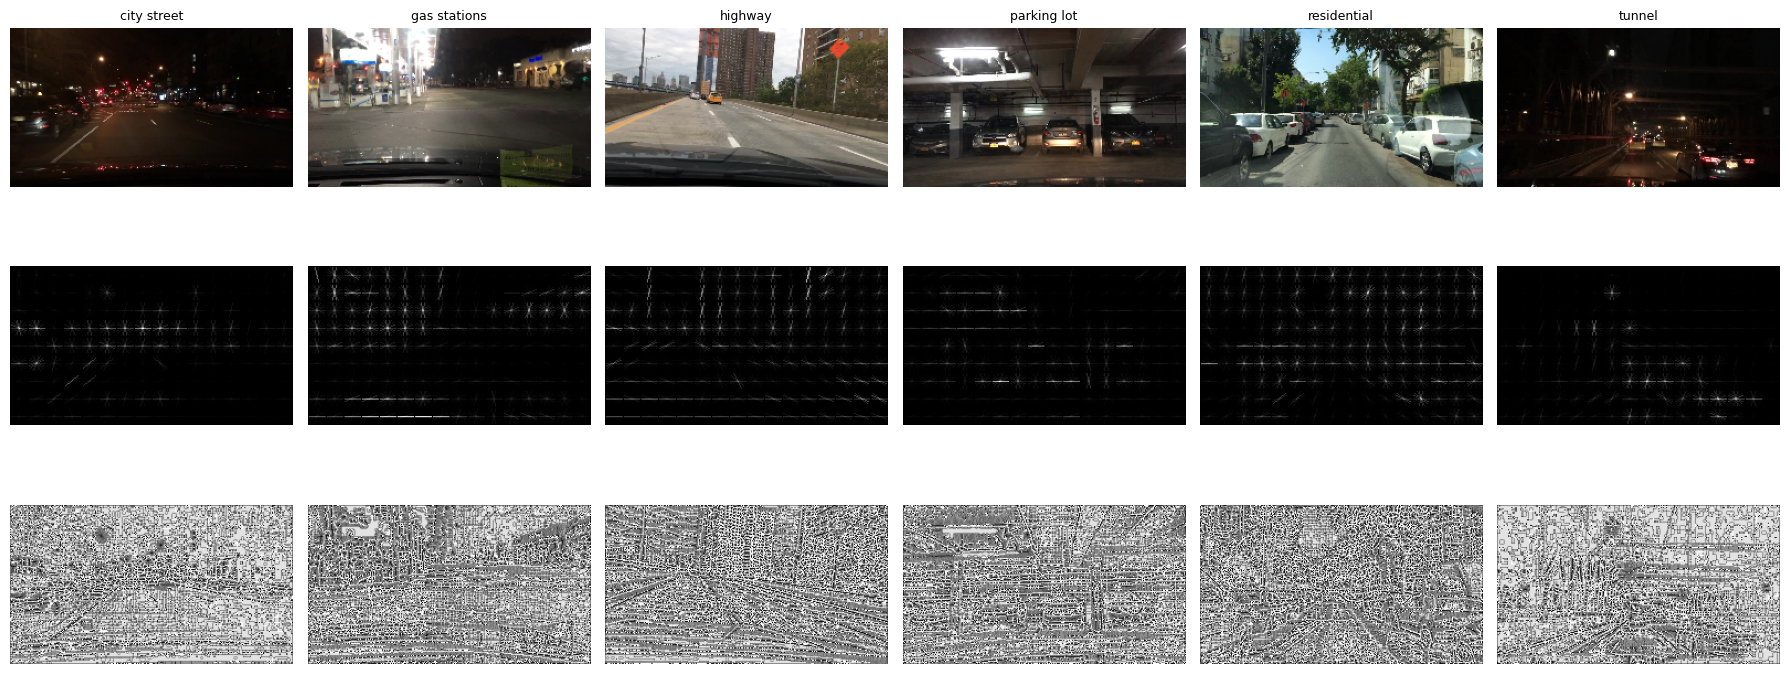

In [10]:
import matplotlib.pyplot as plt
from skimage.feature import hog as hog_vis

classes = sorted(sample['scene'].unique())
fig, axes = plt.subplots(3, len(classes), figsize=(3*len(classes), 8))
for j, c in enumerate(classes):
    p = sample[sample['scene'] == c]['img_path'].iloc[0]
    img = load_img(p)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, hog_img = hog_vis(gray, orientations=9, pixels_per_cell=(16,16),
                         cells_per_block=(2,2), visualize=True)
    lbp = local_binary_pattern(gray, 8, 1, method='uniform')
    axes[0, j].imshow(img);              axes[0, j].set_title(c, fontsize=9)
    axes[1, j].imshow(hog_img, cmap='gray')
    axes[2, j].imshow(lbp, cmap='gray')
    for i in range(3): axes[i, j].axis('off')
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('HOG'); axes[2,0].set_ylabel('LBP')
plt.tight_layout(); plt.show()

## 9. Dataset variation: mean brightness by class

100%|██████████| 4217/4217 [00:22<00:00, 190.09it/s]


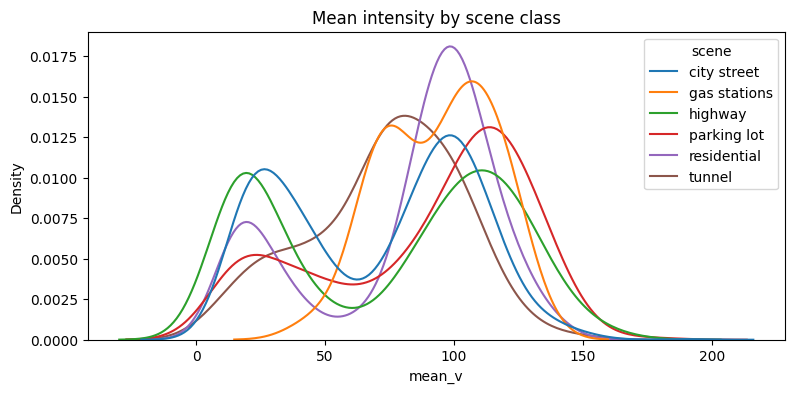

In [11]:
import seaborn as sns

sample['mean_v'] = [load_img(p)[:,:,:].mean() for p in tqdm(sample['img_path'])]
plt.figure(figsize=(9,4))
sns.kdeplot(data=sample, x='mean_v', hue='scene', common_norm=False)
plt.title('Mean intensity by scene class'); plt.show()

## 10. PCA explained variance — all 7 feature types

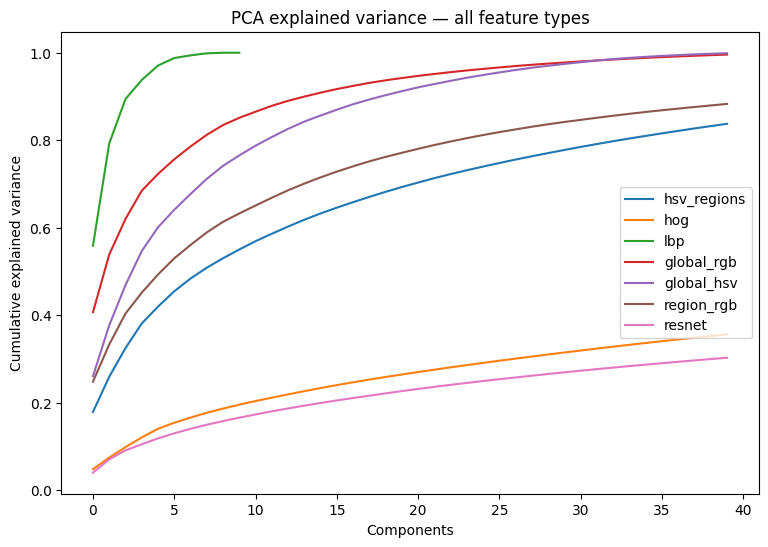

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(9, 6))
for name in results:
    Xs = StandardScaler().fit_transform(results[name]['X'])
    n_comp = min(40, Xs.shape[1])
    pca = PCA(n_components=n_comp).fit(Xs)
    plt.plot(np.cumsum(pca.explained_variance_ratio_), label=name)
plt.xlabel('Components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.title('PCA explained variance — all feature types')
plt.show()

## 11. t-SNE — all 7 feature types side by side

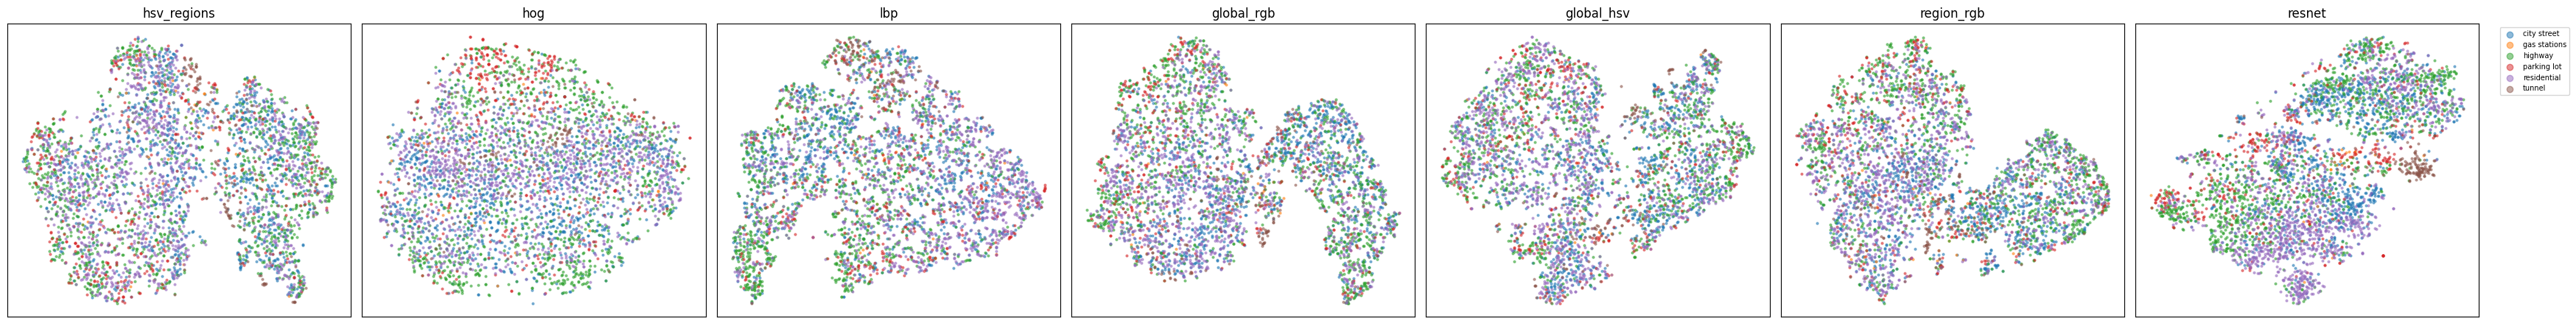

In [13]:
from sklearn.manifold import TSNE

feature_names = list(results.keys())
fig, axes = plt.subplots(1, len(feature_names), figsize=(5*len(feature_names), 4.5))
for ax, name in zip(axes, feature_names):
    Xs = StandardScaler().fit_transform(results[name]['X'])
    n_comp = min(30, Xs.shape[1])
    Xp = PCA(n_components=n_comp).fit_transform(Xs)
    emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Xp)
    for c in classes:
        m = y == c
        ax.scatter(emb[m, 0], emb[m, 1], s=4, alpha=0.5, label=c)
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(markerscale=3, fontsize=7, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 12. Feature summary table

| Feature | Type | Dims | What it captures |
|---|---|---|---|
| Region-wise HSV histograms | Simple (primary) | 144 | Color distribution over top/middle/bottom bands — sky-structure-road stratification. |
| Histogram of Oriented Gradients (HOG) | Simple | 4,320 | Edge density and orientation — structural layout. |
| Local Binary Patterns (LBP) | Simple | 10 | Micro-texture — cheap, efficiency-side baseline. |
| Global RGB histogram | Simple (ablation) | 48 | Whole-image color distribution, no spatial info. Highest PCA compressibility. |
| Global HSV histogram | Simple (ablation) | 48 | Whole-image color, brightness/hue separated. |
| Region-wise RGB histogram | Simple (ablation) | 144 | Top/middle/bottom band color, no hue/brightness separation. |
| ResNet50 embeddings | Complex | 2,048 | Penultimate-layer activations of an ImageNet-pretrained CNN. |

## 13. Color histogram ablation — write-up

**Color histogram ablation: global vs. region-wise, RGB vs. HSV.** To validate the design choice of region-wise HSV histograms over simpler alternatives, we extracted four color-histogram variants on the same dev sample (global RGB, global HSV, region-wise RGB, region-wise HSV) and compared them via PCA and t-SNE. PCA explained-variance curves show global histograms are substantially more compressible than region-wise ones (reaching ~100% cumulative variance by ~35 components vs. ~85-88% for region-wise at the same budget), and RGB compresses faster than HSV within each grouping. This is consistent with expectation rather than a weakness: RGB's channels are correlated (brightness shifts move R, G, and B together), so early components capture most of its variance, while HSV's explicit separation of hue from brightness — and region-wise splitting's deliberate capture of distinct top/middle/bottom information — spread real signal across more dimensions instead of compressing away information. t-SNE visualization, however, shows all four variants produce heavily overlapping class clusters, with none approaching the separation seen in the ResNet embeddings. The clearest partial separation appears between city street and highway (consistent with their differing openness and color composition) and small tunnel sub-clusters (consistent with tunnels' distinctive dark, artificially-lit color signature), while residential, parking lot, and gas stations show essentially no visual separation in any variant — likely compounded by the severe sample scarcity in the latter two classes. Region-wise histograms did not show a clear visual separability advantage over global histograms in 2D t-SNE space despite carrying more non-redundant information per PCA. This confirms that color alone provides weak-to-moderate signal for scene classification — sufficient for some open-vs-enclosed distinctions but not for the finer-grained classes — reinforcing the motivation for combining color features with structural (HOG) and learned (ResNet) representations rather than relying on color histograms in isolation.

In [19]:
from sklearn.model_selection import train_test_split
import pandas as pd

def get_splits(feature_name,results, y, test_size= 0.15, val_size = 0.15, random_state = 1234, verbose = True):
  """
  Select a feature type from 'results' and split into train/test/val
  """
  X = results[feature_name]['X']
  X_temp, X_test,Y_temp, Y_test = train_test_split( X, y, test_size=test_size, random_state=random_state, stratify=y)

  relative_val_size = val_size / (1 - test_size)
  X_train, X_val, Y_train, Y_val = train_test_split( X_temp, Y_temp, test_size=relative_val_size, random_state=random_state, stratify=Y_temp)


  # if verbose:
  #   print(f"Feature: {feature_name}  (dims={X.shape[1]})")
  #   print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
  #   print()
  #   counts = pd.DataFrame({
  #       'train': pd.Series(Y_train).value_counts(),
  #       'val': pd.Series(Y_val).value_counts(),
  #       'test': pd.Series(Y_test).value_counts(),
  #   }).fillna(0).astype(int)
  #   print(counts)


  return X_train, X_val, X_test, Y_train, Y_val, Y_test





Feature: resnet  (dims=2048)
Train: 2951  Val: 633  Test: 633

              train  val  test
city street     840  180   180
gas stations     24    5     5
highway         840  180   180
parking lot     299   64    64
residential     840  180   180
tunnel          108   24    24


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

X_train, X_val, X_test, y_train, y_val, y_test = get_splits('resnet', results, y)

model= LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred= model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Feature: resnet  (dims=2048)
Train: 2951  Val: 633  Test: 633

              train  val  test
city street     840  180   180
gas stations     24    5     5
highway         840  180   180
parking lot     299   64    64
residential     840  180   180
tunnel          108   24    24
Accuracy: 0.6097946287519748
[[ 93   0  45   8  34   0]
 [  1   2   1   0   1   0]
 [ 29   0 113   6  27   5]
 [  5   0   6  40  12   1]
 [ 35   0  23   3 119   0]
 [  1   0   4   0   0  19]]
